<a href="https://colab.research.google.com/github/AbdullahJalab/student-performance-prediction-bkt/blob/main/AFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


def train_afm(data):

    # Remove hints
    data = data[data["Error"].notna()].copy()

    # Target
    y = data["Error"].values

    # Build AFM features
    feature_rows = []

    for _, row in data.iterrows():

        feature_rows.append({"KC": row["kc_col"],"opportunity": row["opportunity_col"],} )

    # Convert to feature matrix
    vectorizer = DictVectorizer()

    X = vectorizer.fit_transform(feature_rows)

    # Student groups
    students = data["student_col"].values

    # Train/Test split
    splitter = GroupShuffleSplit(n_splits=1,test_size=0.2,random_state=42, )

    train_idx, test_idx = next(splitter.split(X,y,groups=students, ))

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    # Train AFM
    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, y_train)

    # Predict probability of error
    y_prob = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, thresholds = roc_curve(y_test,y_prob,)

    auc = roc_auc_score(y_test,y_prob,)

    # Optimal threshold
    scores = tpr + (1 - fpr)

    best_idx = np.argmax(scores)

    opt_t = thresholds[best_idx]

    print("AUC:", auc)
    print("Optimal threshold:", opt_t)

    # ROC plot
    plt.figure()

    plt.plot(fpr,tpr,linewidth=2,)

    plt.plot([0, 1],[0, 1],"--",)

    plt.scatter(fpr[best_idx],tpr[best_idx],)

    plt.xlabel("1-Specificity")
    plt.ylabel("Sensitivity")
    plt.title("ROC Curve - AFM")

    plt.show()

    # Precision Recall
    precision, recall, _ = precision_recall_curve(y_test,y_prob,  )

    plt.figure()

    plt.plot(recall,precision,linewidth=2, )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision Recall Curve - AFM")

    plt.show()

    # Final classification
    pred_label = (y_prob >= opt_t).astype(int)

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        pred_label,
    )

    print("Confusion Matrix:")
    print(cm)

    print("Accuracy:", accuracy_score(y_test, pred_label))
    print("Precision:", precision_score(y_test, pred_label))
    print("Recall:", recall_score(y_test, pred_label))
    print("F1:", f1_score(y_test, pred_label))

    return model

                            student_col  pred_col            kc_col  \
0  Stu_00f382876a4ce3a5d2e9ca1a575a68a9     0.008   compDragLargest   
1  Stu_00f382876a4ce3a5d2e9ca1a575a68a9     0.000    compDragMiddle   
2  Stu_00f382876a4ce3a5d2e9ca1a575a68a9     0.000    equivDragFract   
3  Stu_00f382876a4ce3a5d2e9ca1a575a68a9     0.000    equivDragFract   
4  Stu_00f382876a4ce3a5d2e9ca1a575a68a9     0.569  equivMultiplyNum   

  outcome_col  opportunity_col  Row  Error  
0   incorrect                4   23    1.0  
1   incorrect                6   35    1.0  
2     correct               17   38    0.0  
3     correct               20   45    0.0  
4     correct                1   59    0.0  
AUC: 0.6866556010651637
Optimal threshold: 0.2892475613999383


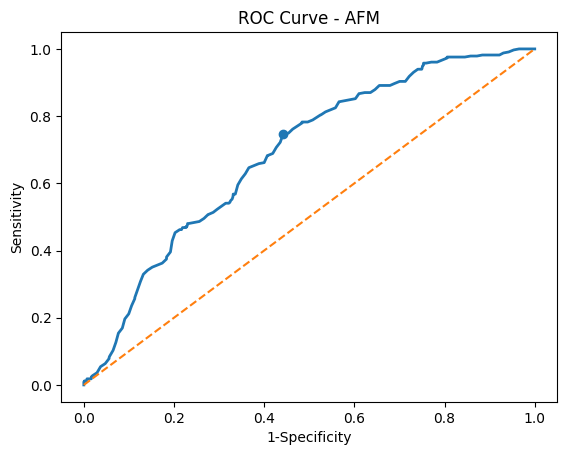

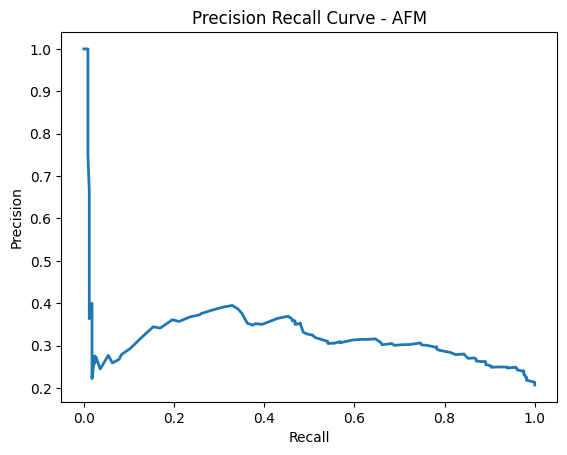

Confusion Matrix:
[[706 559]
 [ 84 247]]
Accuracy: 0.5971177944862155
Precision: 0.3064516129032258
Recall: 0.7462235649546828
F1: 0.43447669305189096


LogisticRegression(max_iter=1000)

In [6]:
import pandas as pd
data = pd.read_excel(
    "/content/zpd/data/interim/fractions_cleaned.xlsx"
)

print(data.head())

train_afm(data)